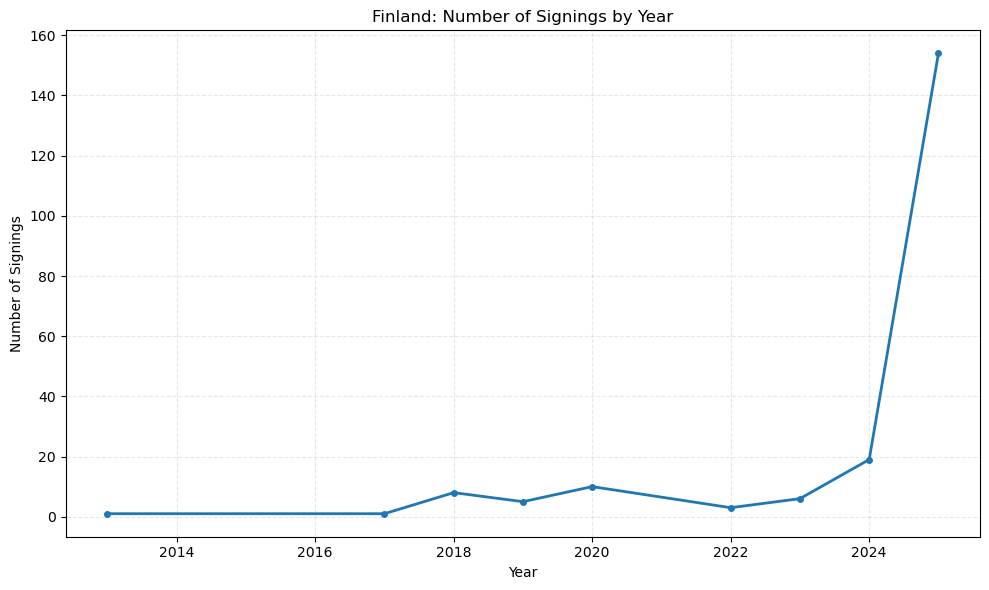

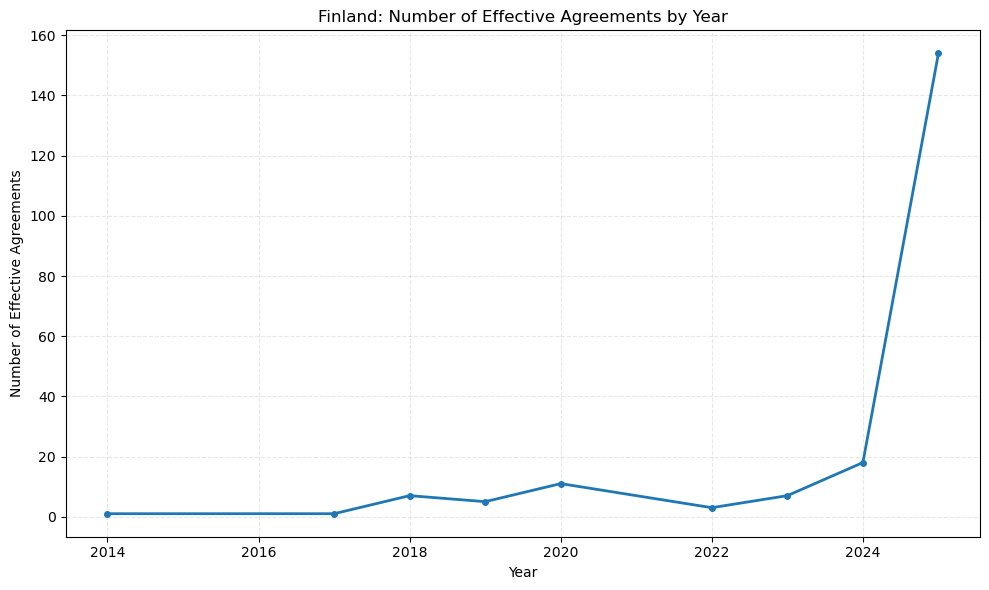

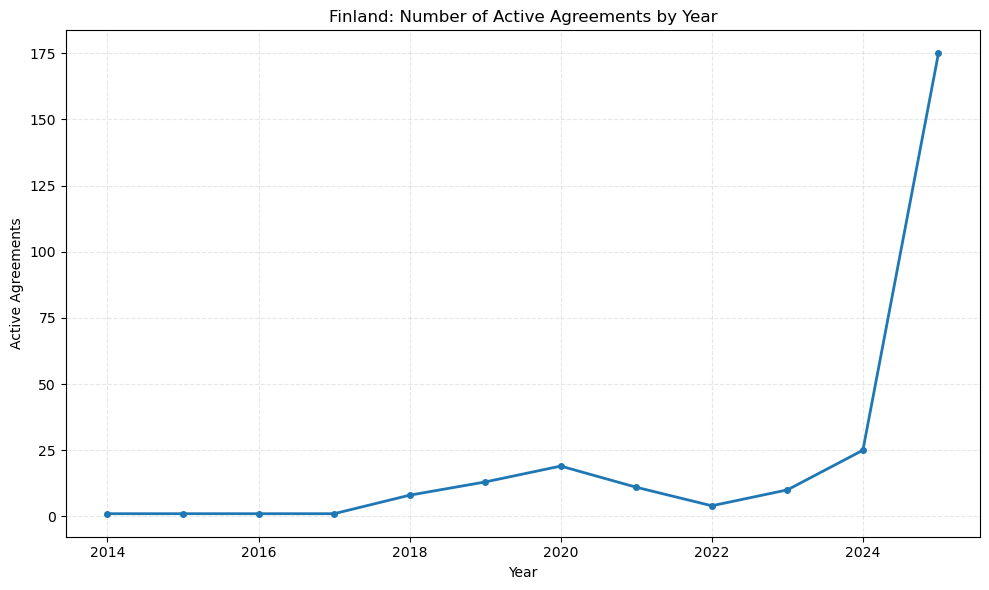

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# 1. Load the Finland dataset
# Using 'on_bad_lines' to handle formatting inconsistencies in the CSV
df_finland = pd.read_csv('finland_metadata.csv', on_bad_lines='skip')

# 2. Map and parse date columns
# Finland's date format in the CSV is Day.Month.Year (DD.MM.YYYY)
col_signing = 'Date of signature of collective agreement'
col_effective = 'Date of entry into force of collective agreement'
col_expiry = 'Expiry date of collective agreement'

df_finland['date_signing'] = pd.to_datetime(df_finland[col_signing], format='%d.%m.%Y', errors='coerce')
df_finland['date_effective'] = pd.to_datetime(df_finland[col_effective], format='%d.%m.%Y', errors='coerce')
df_finland['date_expiry'] = pd.to_datetime(df_finland[col_expiry], format='%d.%m.%Y', errors='coerce')

# --- PLOT 1: SIGNING DATES BY YEAR ---
# Filter for years before 2026
df_signing = df_finland[df_finland['date_signing'].dt.year < 2026].dropna(subset=['date_signing'])
counts_signing = df_signing['date_signing'].dt.year.value_counts().sort_index()

plt.figure(figsize=(10, 6), facecolor='white')
plt.plot(counts_signing.index, counts_signing.values, marker='o', markersize=4, linewidth=2)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('Finland: Number of Signings by Year')
plt.xlabel('Year')
plt.ylabel('Number of Signings')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('finland_plot_signing.png')


# --- PLOT 2: EFFECTIVE DATES BY YEAR ---
# Filter for years before 2026
df_effective = df_finland[df_finland['date_effective'].dt.year < 2026].dropna(subset=['date_effective'])
counts_effective = df_effective['date_effective'].dt.year.value_counts().sort_index()

plt.figure(figsize=(10, 6), facecolor='white')
plt.plot(counts_effective.index, counts_effective.values, marker='o', markersize=4, linewidth=2)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('Finland: Number of Effective Agreements by Year')
plt.xlabel('Year')
plt.ylabel('Number of Effective Agreements')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('finland_plot_effective.png')


# --- PLOT 3: NUMBER OF ACTIVE AGREEMENTS BY YEAR ---
df_active_raw = df_finland.dropna(subset=['date_effective', 'date_expiry'])
if not df_active_raw.empty:
    start_year = int(df_active_raw['date_effective'].dt.year.min())
    # Exclude 2026 by ending the range at 2025
    end_year = 2025 
    years_range = range(start_year, end_year + 1)
    counts_active = []

    for year in years_range:
        check_date = pd.Timestamp(year=year, month=12, day=31)
        # Active if: Started on/before year-end AND ends on/after year-end
        count = ((df_active_raw['date_effective'] <= check_date) & 
                 (df_active_raw['date_expiry'] >= check_date)).sum()
        counts_active.append(count)

    plt.figure(figsize=(10, 6), facecolor='white')
    plt.plot(years_range, counts_active, marker='o', markersize=4, linewidth=2)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.title('Finland: Number of Active Agreements by Year')
    plt.xlabel('Year')
    plt.ylabel('Active Agreements')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig('finland_plot_active.png')

plt.show()